In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Dataset load
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (455, 30)
Test size: (114, 30)


In [2]:
import numpy as np

# No DP model
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
accuracy_no_dp = accuracy_score(y_test, y_pred)

# Confidence
train_conf = model.predict_proba(X_train).max(axis=1)
test_conf = model.predict_proba(X_test).max(axis=1)

print("=== NO DP MODEL ===")
print("Accuracy:", accuracy_no_dp)
print("Train confidence:", np.mean(train_conf))
print("Test confidence:", np.mean(test_conf))
print("Gap:", abs(np.mean(train_conf) - np.mean(test_conf)))

=== NO DP MODEL ===
Accuracy: 0.9649122807017544
Train confidence: 0.9984212919623028
Test confidence: 0.9875968919175335
Gap: 0.010824400044769256


In [3]:
def add_noise(X, noise_level):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

In [4]:
# DP High ε -> low noise
X_train_dp_high = add_noise(X_train, 0.05)

model_high = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=1000,
    random_state=42
)

model_high.fit(X_train_dp_high, y_train)

y_pred_high = model_high.predict(X_test)
acc_high = accuracy_score(y_test, y_pred_high)

train_conf_high = model_high.predict_proba(X_train).max(axis=1)
test_conf_high = model_high.predict_proba(X_test).max(axis=1)

print("=== DP HIGH ε MODEL ===")
print("Accuracy:", acc_high)
print("Train confidence:", np.mean(train_conf_high))
print("Test confidence:", np.mean(test_conf_high))
print("Gap:", abs(np.mean(train_conf_high) - np.mean(test_conf_high)))

=== DP HIGH ε MODEL ===
Accuracy: 0.9649122807017544
Train confidence: 0.99699571286012
Test confidence: 0.9879738962277009
Gap: 0.009021816632419077


In [5]:
# DP Low ε -> higher noise
X_train_dp_low = add_noise(X_train, 0.2)

model_low = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=1000,
    random_state=42
)

model_low.fit(X_train_dp_low, y_train)

y_pred_low = model_low.predict(X_test)
acc_low = accuracy_score(y_test, y_pred_low)

train_conf_low = model_low.predict_proba(X_train).max(axis=1)
test_conf_low = model_low.predict_proba(X_test).max(axis=1)

print("=== DP LOW ε MODEL ===")
print("Accuracy:", acc_low)
print("Train confidence:", np.mean(train_conf_low))
print("Test confidence:", np.mean(test_conf_low))
print("Gap:", abs(np.mean(train_conf_low) - np.mean(test_conf_low)))

=== DP LOW ε MODEL ===
Accuracy: 0.9649122807017544
Train confidence: 0.9954286338271928
Test confidence: 0.9925380681046213
Gap: 0.0028905657225715142


In [6]:
print("\n=== FINAL RESULT ===")

print("No DP:")
print("Accuracy:", accuracy_no_dp)
print("Train:", np.mean(train_conf))
print("Test:", np.mean(test_conf))
print("Gap:", abs(np.mean(train_conf) - np.mean(test_conf)))

print("\nDP High ε:")
print("Accuracy:", acc_high)
print("Train:", np.mean(train_conf_high))
print("Test:", np.mean(test_conf_high))
print("Gap:", abs(np.mean(train_conf_high) - np.mean(test_conf_high)))

print("\nDP Low ε:")
print("Accuracy:", acc_low)
print("Train:", np.mean(train_conf_low))
print("Test:", np.mean(test_conf_low))
print("Gap:", abs(np.mean(train_conf_low) - np.mean(test_conf_low)))


=== FINAL RESULT ===
No DP:
Accuracy: 0.9649122807017544
Train: 0.9984212919623028
Test: 0.9875968919175335
Gap: 0.010824400044769256

DP High ε:
Accuracy: 0.9649122807017544
Train: 0.99699571286012
Test: 0.9879738962277009
Gap: 0.009021816632419077

DP Low ε:
Accuracy: 0.9649122807017544
Train: 0.9954286338271928
Test: 0.9925380681046213
Gap: 0.0028905657225715142


In [8]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# noise function (DP simulation)
def add_noise(X, noise_level):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

noise_levels = [0.05, 0.1, 0.15, 0.2, 0.25]

results = []

print("=== SEARCHING BEST NOISE (ε) ===")

for n in noise_levels:
    # add noise
    X_noisy = add_noise(X_train, n)
    
    # model
    model_temp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        max_iter=1000,
        random_state=42
    )
    
    # train
    model_temp.fit(X_noisy, y_train)
    
    # predict
    y_pred_temp = model_temp.predict(X_test)
    
    # accuracy
    acc = accuracy_score(y_test, y_pred_temp)
    
    # confidence
    train_conf_temp = model_temp.predict_proba(X_train).max(axis=1)
    test_conf_temp = model_temp.predict_proba(X_test).max(axis=1)
    
    gap = abs(np.mean(train_conf_temp) - np.mean(test_conf_temp))
    
    results.append((n, acc, gap))
    
    print(f"\nNoise: {n}")
    print("Accuracy:", acc)
    print("Gap:", gap)

# BEST RESULT FINDING
best = sorted(results, key=lambda x: (-x[1], x[2]))[0]

print("\n=== BEST CONFIGURATION ===")
print("Best Noise (ε):", best[0])
print("Best Accuracy:", best[1])
print("Best Gap:", best[2])

=== SEARCHING BEST NOISE (ε) ===

Noise: 0.05
Accuracy: 0.9824561403508771
Gap: 0.010007395149737142

Noise: 0.1
Accuracy: 0.9736842105263158
Gap: 0.008185905375378

Noise: 0.15
Accuracy: 0.9824561403508771
Gap: 0.004549648456723121

Noise: 0.2
Accuracy: 0.956140350877193
Gap: 0.00910458586342111

Noise: 0.25
Accuracy: 0.9649122807017544
Gap: 0.0054812509833319645

=== BEST CONFIGURATION ===
Best Noise (ε): 0.15
Best Accuracy: 0.9824561403508771
Best Gap: 0.004549648456723121


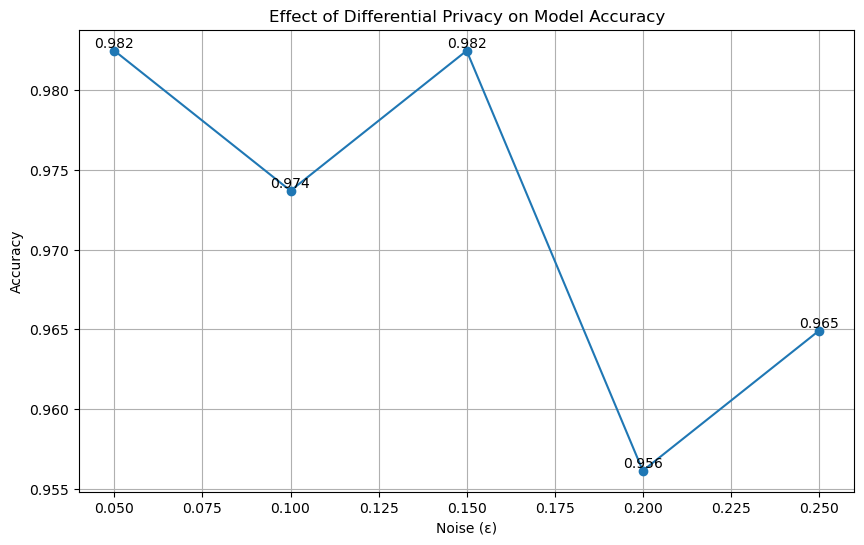

In [12]:
import matplotlib.pyplot as plt

noise = [r[0] for r in results]
accuracy = [r[1] for r in results]

plt.figure(figsize=(10,6))

plt.plot(noise, accuracy, marker='o')

# value дээр бичих
for x, y in zip(noise, accuracy):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

plt.xlabel("Noise (ε)")
plt.ylabel("Accuracy")
plt.title("Effect of Differential Privacy on Model Accuracy")

plt.grid(True)

plt.show()

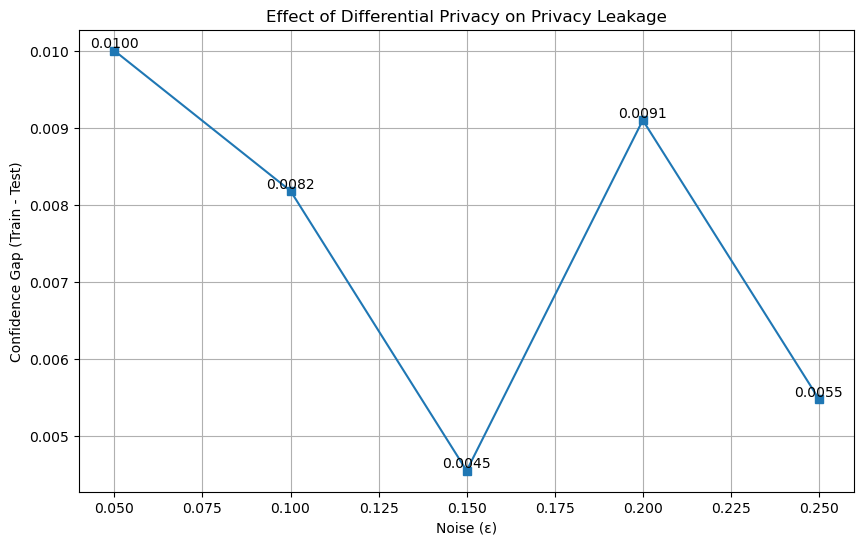

In [13]:
gap = [r[2] for r in results]

plt.figure(figsize=(10,6))

plt.plot(noise, gap, marker='s')

# value дээр бичих
for x, y in zip(noise, gap):
    plt.text(x, y, f"{y:.4f}", ha='center', va='bottom')

plt.xlabel("Noise (ε)")
plt.ylabel("Confidence Gap (Train - Test)")
plt.title("Effect of Differential Privacy on Privacy Leakage")

plt.grid(True)

plt.show()